In [1]:
import os
from pathlib import Path
import numpy as np
from tqdm import tqdm

import plotly.graph_objects as go
from Bio.PDB import PDBParser
import py3Dmol

from mdm2_breaker import ProteinFeaturizer, SmallMoleculeFeaturizer

ROOT = Path(os.getcwd()).parents[0]

In [2]:
pdb_file = os.path.join(ROOT, "data", "MDM2_Breaker", "1YCR.pdb")
mol_file = os.path.join(ROOT, "data", "MDM2_Breaker", "bindingdb_p53_binding_protein_mdm2.tsv")

## Parse the Protein

In [3]:
protein = ProteinFeaturizer(pdb_file = pdb_file)
coords, _ = protein._parse_structure()
coords.shape

(98, 3)

In [4]:
coords[None, :, :].shape

(1, 98, 3)

In [5]:
coords[:, None, :].shape

(98, 1, 3)

In [6]:
(coords[:, None, :] - coords[None, :, :])

array([[[  0.        ,   0.        ,   0.        ],
        [ -2.5320005 ,  -0.51799965,  -2.803     ],
        [ -3.7390003 ,  -4.045     ,  -2.1200001 ],
        ...,
        [ -8.318     ,   9.419001  ,  -2.242     ],
        [ -7.0150003 ,   6.8050003 ,   0.20499992],
        [ -5.023     ,   4.7649994 ,  -2.302     ]],

       [[  2.5320005 ,   0.51799965,   2.803     ],
        [  0.        ,   0.        ,   0.        ],
        [ -1.2069998 ,  -3.5270004 ,   0.68299997],
        ...,
        [ -5.7859993 ,   9.937     ,   0.561     ],
        [ -4.483     ,   7.323     ,   3.008     ],
        [ -2.4909992 ,   5.282999  ,   0.50100005]],

       [[  3.7390003 ,   4.045     ,   2.1200001 ],
        [  1.2069998 ,   3.5270004 ,  -0.68299997],
        [  0.        ,   0.        ,   0.        ],
        ...,
        [ -4.5789995 ,  13.464001  ,  -0.12199998],
        [ -3.276     ,  10.85      ,   2.325     ],
        [ -1.2839994 ,   8.809999  ,  -0.18199992]],

       ...,

      

In [7]:
import torch
distances = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)
src, dst = np.where((distances < 8) & (distances > 0))
edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_index.t()


/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_97848/1513980429.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)


tensor([[ 0,  1],
        [ 0,  2],
        [ 0, 24],
        ...,
        [97, 26],
        [97, 95],
        [97, 96]])

In [8]:
(coords[:, None, :] - coords[None, :, :]).shape

(98, 98, 3)

In [9]:
np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1).shape

(98, 98)

In [10]:
coords

array([[ 11.124, -13.382,  -4.414],
       [ 13.656, -12.864,  -1.611],
       [ 14.863,  -9.337,  -2.294],
       [ 18.243,  -8.753,  -0.623],
       [ 20.65 ,  -5.812,  -0.577],
       [ 24.328,  -6.842,  -0.726],
       [ 26.812,  -5.44 ,   1.782],
       [ 29.752,  -3.21 ,   0.585],
       [ 32.37 ,  -5.908,  -0.059],
       [ 29.801,  -8.16 ,  -1.765],
       [ 28.366,  -5.336,  -3.833],
       [ 31.883,  -4.57 ,  -5.132],
       [ 32.387,  -8.279,  -5.983],
       [ 29.03 ,  -8.111,  -7.813],
       [ 29.764,  -4.979,  -9.833],
       [ 33.022,  -6.663, -10.783],
       [ 30.957,  -9.077, -12.896],
       [ 28.554,  -6.605, -14.461],
       [ 25.767,  -6.605, -11.863],
       [ 25.131,  -2.841, -11.765],
       [ 22.587,  -2.545,  -8.939],
       [ 21.717,  -2.334,  -5.253],
       [ 18.826,  -4.769,  -4.826],
       [ 18.751,  -8.419,  -5.918],
       [ 16.819, -11.63 ,  -5.577],
       [ 18.794, -14.502,  -3.998],
       [ 19.082, -16.054,  -7.492],
       [ 20.876, -13.065,  -

In [11]:
def view_protein(pdb_file, highlight_chain="A"):
    view = py3Dmol.view(query=pdb_file)

    # Show the whole protein as a "Cartoon" (Ribbon)
    view.setStyle({"cartoon": {"color": "spectrum"}})

    # Show the Alpha Carbons as spheres
    view.addStyle(
        {"chain": highlight_chain, "atom": "CA"},
        {"sphere": {"radius": 0.5, "color": "red"}},
    )

    view.zoomTo()
    view.show()

view_protein(pdb_file)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [12]:
def plot_beads(coords, title="MDM2 Alpha Carbons"):
    x, y, z = coords.T

    x_plot, y_plot, z_plot = [], [], []
    for i in range(len(coords) - 1):
        # Add current point
        x_plot.append(x[i])
        y_plot.append(y[i])
        z_plot.append(z[i])
        
        # Check physics: Distance to next point
        dist = np.linalg.norm(coords[i] - coords[i+1])
        # Break the line if distance is more than the 3.8A peptide bond
        if dist > 4.0:             
            x_plot.append(None)
            y_plot.append(None)
            z_plot.append(None)
            
    # Add the very last point
    x_plot.append(x[-1])
    y_plot.append(y[-1])
    z_plot.append(z[-1])

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=x_plot,
                y=y_plot,
                z=z_plot,
                mode="markers+lines",  # Lines connect the sequence backbone
                marker=dict(size=5, color=z, colorscale="Viridis", opacity=0.8),
                line=dict(color="darkblue", width=2),
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="X (Å)", yaxis_title="Y (Å)", zaxis_title="Z (Å)"),
        margin=dict(l=0, r=0, b=0, t=0),
    )

    fig.show()


plot_beads(coords)

In [13]:
protein.get_graph()

Data(x=[98, 20], edge_index=[864, 2], pos=[98, 3])

## Parse the Small Molecules

In [14]:
import pandas as pd

df = pd.read_csv(mol_file, sep='\t', on_bad_lines='skip', low_memory=False)
df.head()

,BindingDB Reactant_set_id,Ligand SMILES,Ligand InChI,Ligand InChI Key,BindingDB MonomerID,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),...,UniProt (SwissProt) Recommended Name of Target Chain 50,UniProt (SwissProt) Entry Name of Target Chain 50,UniProt (SwissProt) Primary ID of Target Chain 50,UniProt (SwissProt) Secondary ID(s) of Target Chain 50,UniProt (SwissProt) Alternative ID(s) of Target Chain 50,UniProt (TrEMBL) Submitted Name of Target Chain 50,UniProt (TrEMBL) Entry Name of Target Chain 50,UniProt (TrEMBL) Primary ID of Target Chain 50,UniProt (TrEMBL) Secondary ID(s) of Target Chain 50,UniProt (TrEMBL) Alternative ID(s) of Target Chain 50
0,51501834,COc1cc(ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@@...,"InChI=1S/C37H44Cl2F2N4O4/c1-36(2,3)18-30-37(25...",XJXDSLJECXYDEY-GXFZAZKKSA-N,50605126,CHEMBL5187340,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.002,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50085387,CC[C@@H](CS(=O)(=O)C(C)(C)C)N1[C@@H]([C@H](C[C...,"InChI=1S/C28H35Cl2NO5S/c1-6-22(17-37(35,36)27(...",AXQMSOFCQLTJGV-ZJTSJXPUSA-N,50448936,"CHEMBL3125527::US9296736, 342::US9593129, Exam...",E3 ubiquitin-protein ligase Mdm2,Homo sapiens,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50309202,CC(C)[C@@H](CS(=O)(=O)C(C)C)N1[C@@H]([C@H](C[C...,"InChI=1S/C28H35Cl2NO5S/c1-17(2)24(16-37(35,36)...",DRLCSJFKKILATL-YWCVFVGNSA-N,50448947,"CHEMBL3125702::US9296736, 362::US9593129, Exam...",E3 ubiquitin-protein ligase Mdm2,Homo sapiens,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,261540,COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...,InChI=1S/C30H29Cl2N3O3/c1-16(2)34-28-26(33-29(...,YJTBLUMJJBCGIZ-UHFFFAOYSA-N,129810,"US8815926, 89",E3 ubiquitin-protein ligase Mdm2,Homo sapiens,NaN,0.04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,51094969,CC(C)[C@@H](CS(=O)(=O)C(C)C)N1[C@@H]([C@H](C[C...,"InChI=1S/C28H35Cl2NO5S/c1-17(2)24(16-37(35,36)...",DRLCSJFKKILATL-YWCVFVGNSA-N,50448947,"CHEMBL3125702::US9296736, 362::US9593129, Exam...",E3 ubiquitin-protein ligase Mdm2,Homo sapiens,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.columns

Index(['BindingDB Reactant_set_id', 'Ligand SMILES', 'Ligand InChI',
       'Ligand InChI Key', 'BindingDB MonomerID', 'BindingDB Ligand Name',
       'Target Name',
       'Target Source Organism According to Curator or DataSource', 'Ki (nM)',
       'IC50 (nM)',
       ...
       'UniProt (SwissProt) Recommended Name of Target Chain 50',
       'UniProt (SwissProt) Entry Name of Target Chain 50',
       'UniProt (SwissProt) Primary ID of Target Chain 50',
       'UniProt (SwissProt) Secondary ID(s) of Target Chain 50',
       'UniProt (SwissProt) Alternative ID(s) of Target Chain 50',
       'UniProt (TrEMBL) Submitted Name of Target Chain 50',
       'UniProt (TrEMBL) Entry Name of Target Chain 50',
       'UniProt (TrEMBL) Primary ID of Target Chain 50',
       'UniProt (TrEMBL) Secondary ID(s) of Target Chain 50',
       'UniProt (TrEMBL) Alternative ID(s) of Target Chain 50'],
      dtype='object', length=640)

In [16]:
all(df["Target Name"].astype(str).str.contains("mdm2", case=False))

True

In [17]:
df["Target Name"].value_counts()

Target Name
E3 ubiquitin-protein ligase Mdm2    5283
Name: count, dtype: int64

In [18]:
label_columns = ["IC50 (nM)", "Kd (nM)", "Ki (nM)"]
df[label_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5283 entries, 0 to 5282
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   IC50 (nM)  4055 non-null   object
 1   Kd (nM)    186 non-null    object
 2   Ki (nM)    797 non-null    object
dtypes: object(3)
memory usage: 123.9+ KB


In [19]:
df[label_columns]

,IC50 (nM),Kd (nM),Ki (nM)
0,NaN,NaN,0.002
1,NaN,0.036000,NaN
2,NaN,0.038,NaN
3,0.04,NaN,NaN
4,NaN,0.045000,NaN
...,...,...,...
5278,NaN,NaN,27840
5279,NaN,NaN,28000
5280,NaN,NaN,28000
5281,NaN,NaN,28000


<Axes: >

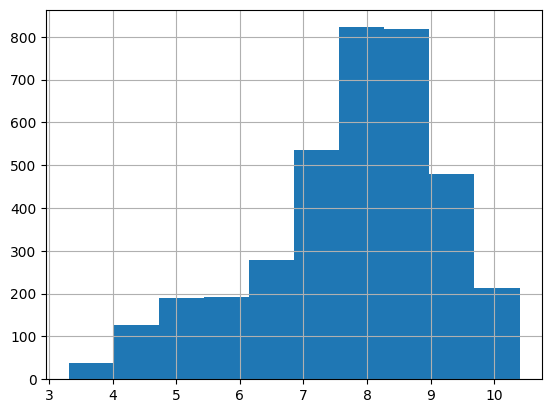

In [20]:
df["IC50_numeric"] = pd.to_numeric(df["IC50 (nM)"], errors='coerce')
df['pIC50'] = -np.log10(df['IC50_numeric'] * 1e-9)

df['pIC50'].hist()

Cleaned Rows: 4055 / 5283


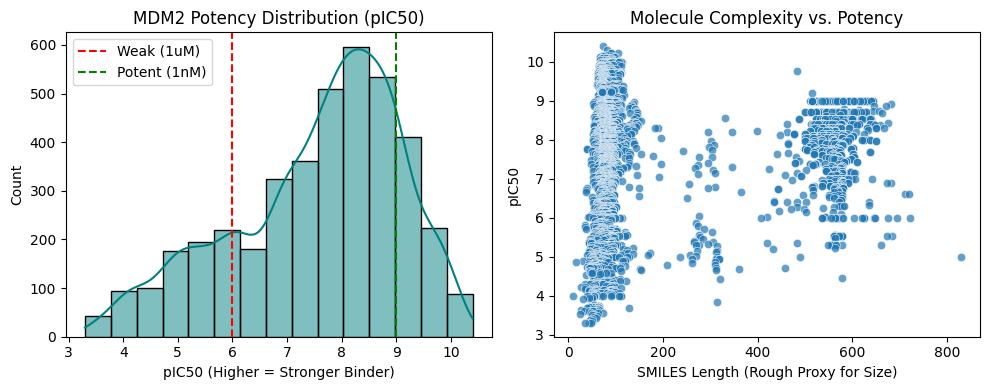

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your sample (Assuming it's already in 'df' from your snippet)
# If reloading: df = pd.read_csv("your_file.tsv", sep='\t', on_bad_lines='skip')

# 2. Clean the IC50 Column (The most important step)
# Regex removes '>' and '<' so we can convert to float
df['IC50_numeric'] = pd.to_numeric(
    df['IC50 (nM)'].astype(str).str.replace(r'[<>]', '', regex=True), 
    errors='coerce'
)

# 3. Create the pIC50 Label (Log-scale potency)
# Formula: -log10(Molar Concentration)
# We limit the max pIC50 to 10.0 to prevent inf values from 0.0 nM
df['pIC50'] = -np.log10(df['IC50_numeric'] * 1e-9)

# Filter out bad conversions (NaNs)
df_clean = df.dropna(subset=['pIC50', 'Ligand SMILES']).copy()

print(f"Cleaned Rows: {len(df_clean)} / {len(df)}")

# 4. EDA Plots
plt.figure(figsize=(10, 4))

# Plot A: The Potency Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_clean['pIC50'], bins=15, kde=True, color='teal')
plt.title('MDM2 Potency Distribution (pIC50)')
plt.xlabel('pIC50 (Higher = Stronger Binder)')
plt.axvline(x=6.0, color='r', linestyle='--', label='Weak (1uM)')
plt.axvline(x=9.0, color='g', linestyle='--', label='Potent (1nM)')
plt.legend()

# Plot B: Molecule Size vs Potency (Sanity Check)
# Longer SMILES usually means bigger molecule. 
# Does bigger = better binder? (Often yes for MDM2 inhibitors)
df_clean['smiles_len'] = df_clean['Ligand SMILES'].str.len()
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean, x='smiles_len', y='pIC50', alpha=0.7)
plt.title('Molecule Complexity vs. Potency')
plt.xlabel('SMILES Length (Rough Proxy for Size)')

plt.tight_layout()
plt.show()

In [22]:
df["Ligand SMILES"]

0       COc1cc(ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@@...
1       CC[C@@H](CS(=O)(=O)C(C)(C)C)N1[C@@H]([C@H](C[C...
2       CC(C)[C@@H](CS(=O)(=O)C(C)C)N1[C@@H]([C@H](C[C...
3       COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...
4       CC(C)[C@@H](CS(=O)(=O)C(C)C)N1[C@@H]([C@H](C[C...
                              ...                        
5278       COc1ccc(NC(C(=O)c2ccc(Cl)cc2)c2ccc(F)cc2Cl)cc1
5279    Nc1cc(cnc1N1CCN(CC1c1ccc(Cl)cc1)C(=O)CC(O)=O)C...
5280      Nc1cc(Cl)cnc1N1CCN(CC1c1ccc(Cl)cc1)C(=O)CC(O)=O
5281    Fc1ccc(cc1)-c1ncn(Cc2ccc(Cl)cc2)c1-c1c([nH]c2c...
5282    Nc1cc(ccc1N1CCN(CC1c1ccc(Cl)cc1)C(=O)CC(O)=O)C...
Name: Ligand SMILES, Length: 5283, dtype: object

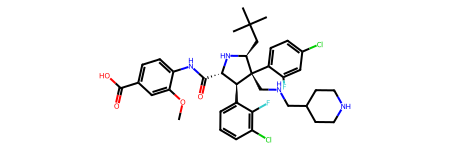

In [23]:
from rdkit import Chem

mol = Chem.MolFromSmiles(df["Ligand SMILES"].iloc[0])
mol


In [24]:
allowed_atoms = [6, 7, 8, 9, 16, 17, 35, 53] # C, N, O, F, P, S, Cl, Br, I
node_feats = []
for atom in mol.GetAtoms():
    an = atom.GetAtomicNum()
    if an in allowed_atoms:
        node_feats.append(allowed_atoms.index(an))
    else:
        node_feats.append(len(allowed_atoms))

x = torch.tensor(node_feats, dtype=torch.long)
print(x.shape)
print(x.unsqueeze(1).shape)

x


torch.Size([49])
torch.Size([49, 1])


tensor([0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 3, 0, 0, 0, 0, 5, 0, 0, 3, 0, 2,
        2])

In [25]:
for bond in mol.GetBonds():
    print(bond.GetBondType())


SINGLE
SINGLE
AROMATIC
AROMATIC
AROMATIC
AROMATIC
AROMATIC
SINGLE
SINGLE
DOUBLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
AROMATIC
AROMATIC
AROMATIC
AROMATIC
SINGLE
AROMATIC
SINGLE
SINGLE
AROMATIC
AROMATIC
AROMATIC
SINGLE
AROMATIC
AROMATIC
SINGLE
SINGLE
SINGLE
DOUBLE
AROMATIC
SINGLE
AROMATIC
AROMATIC
SINGLE


In [26]:
edge_index[1].max()

tensor(97)

In [27]:
row_idx, col_idx = [], []
for bond in mol.GetBonds():
    start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
    row_idx.append(start)
    col_idx.append(end)

edge_index = torch.tensor([row_idx, col_idx], dtype=torch.long)
edge_index.t()

tensor([[ 0,  1],
        [ 1,  2],
        [ 2,  3],
        [ 3,  4],
        [ 4,  5],
        [ 5,  6],
        [ 6,  7],
        [ 7,  8],
        [ 8,  9],
        [ 9, 10],
        [ 9, 11],
        [11, 12],
        [12, 13],
        [13, 14],
        [14, 15],
        [15, 16],
        [15, 17],
        [15, 18],
        [13, 19],
        [19, 20],
        [20, 21],
        [21, 22],
        [22, 23],
        [23, 24],
        [24, 25],
        [25, 26],
        [26, 27],
        [27, 28],
        [19, 29],
        [29, 30],
        [30, 31],
        [31, 32],
        [32, 33],
        [33, 34],
        [34, 35],
        [34, 36],
        [36, 37],
        [19, 38],
        [38, 39],
        [39, 40],
        [40, 41],
        [41, 42],
        [41, 43],
        [43, 44],
        [44, 45],
        [ 4, 46],
        [46, 47],
        [46, 48],
        [ 7,  2],
        [29, 11],
        [36, 30],
        [44, 38],
        [28, 23]])

In [28]:
mol_data = SmallMoleculeFeaturizer(root = os.path.join(ROOT, "data", "MDM2_Breaker"), file_path = mol_file)
mol_data[0]

Processing...
100%|██████████| 4045/4045 [00:01<00:00, 2964.50it/s]
Done!


Data(x=[38, 1], edge_index=[2, 42], y=[1], dtype=torch.float32)

In [35]:
print(mol_data[0].x.shape)
print(mol_data[0].edge_index.shape)
print(mol_data[0].y.shape)


torch.Size([38, 1])
torch.Size([2, 42])
torch.Size([1])


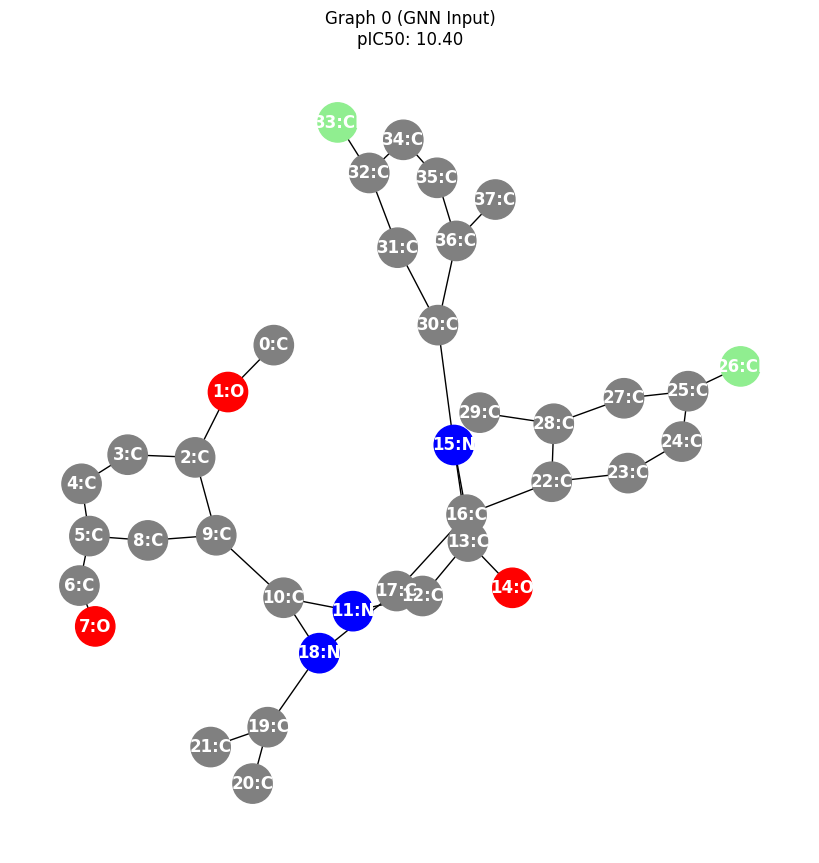

In [37]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def visualize_graph(data, title="Molecule Graph"):
    # 1. Convert PyG Data to NetworkX
    # to_undirected ensures we don't draw two arrows for every bond
    G = to_networkx(data, to_undirected=True)
    
    # 2. Map the "Node Features" back to Element Names
    # Your allowed_atoms list from the featurizer:
    atom_map = {0: 'C', 1: 'N', 2: 'O', 3: 'F', 4: 'S', 5: 'Cl', 6: 'Br', 7: 'I', 8: '?'}
    
    # Create labels and colors for the plot
    labels = {}
    node_colors = []
    
    for node_idx in G.nodes():
        # Get the feature index from the tensor
        # data.x[node_idx] is a tensor like [0], we need the integer 0
        feat_idx = data.x[node_idx].item()
        
        element = atom_map.get(feat_idx, '?')
        labels[node_idx] = f"{node_idx}:{element}" # Format: "Index:Element"
        
        # Color logic (CPK-ish coloring)
        if element == 'C': node_colors.append('gray')
        elif element == 'N': node_colors.append('blue')
        elif element == 'O': node_colors.append('red')
        elif element == 'S': node_colors.append('yellow')
        elif element == 'Cl': node_colors.append('lightgreen')
        else: node_colors.append('orange')

    # 3. Draw it
    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G, seed=42) # Force-directed layout
    
    nx.draw(G, pos, 
            with_labels=True, 
            labels=labels, 
            node_color=node_colors, 
            node_size=800, 
            font_color='white',
            font_weight='bold',
            edge_color='black')
    
    plt.title(f"{title}\npIC50: {data.y.item():.2f}")
    plt.show()

# --- Run it on the first graph ---
visualize_graph(mol_data[0], title="Graph 0 (GNN Input)")